<a href="https://colab.research.google.com/github/andinaufal120/kalimantan-frp-prediction/blob/main/eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis
## Fire Radiative Power (FRP) in Kalimantan 2022–2024

In [1]:
# Import dependencies
from typing import Final

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from dateutil.relativedelta import relativedelta

# Set up Matplotlib graphical backend
%matplotlib inline

In [2]:
# Random state (seed) that will be used for this notebook.
SEED: Final[int] = 42

# Path of the dataset file.
PATH: Final[str] = "./Dataset_ML.csv"

# Directory to save artifacts
FIG_DIR: Final[str] = "./artifacts/figures/"

In [3]:
df = pd.read_csv(PATH)
df['acq_date'] = pd.to_datetime(df['acq_date'])
df['year'] = df['acq_date'].dt.year
df['month'] = df['acq_date'].dt.month
df['year_month'] = df['acq_date'].dt.to_period('M')

# Drop columns decided before EDA:
# - satellite: identifier, not a feature, single unique value only
# - is_dry_season: dropped per lecturer suggestion to let the models learn by their own
# - oni_index, dmi_index: monthly constants, redundant with daily ERA5
df.drop(columns=['satellite', 'is_dry_season', 'oni_index', 'dmi_index'], inplace=True)

row, col = df.shape
print(f"Loaded {row} rows, {col} cols.")

Loaded 59155 rows, 45 cols.


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 59155 entries, 0 to 59154
Data columns (total 45 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   latitude                59155 non-null  float64       
 1   longitude               59155 non-null  float64       
 2   acq_date                59155 non-null  datetime64[us]
 3   acq_time                59155 non-null  float64       
 4   frp                     59155 non-null  float64       
 5   ndvi                    59155 non-null  float64       
 6   evi                     59155 non-null  float64       
 7   ndvi_age_days           59155 non-null  float64       
 8   ndwi                    59155 non-null  float64       
 9   lst_day                 59155 non-null  float64       
 10  lst_night               59155 non-null  float64       
 11  land_cover_type         59155 non-null  float64       
 12  peat_type_class         59155 non-null  float64       
 1

In [5]:
df.head(10)

,latitude,longitude,acq_date,acq_time,frp,ndvi,evi,ndvi_age_days,ndwi,lst_day,...,frp_log1p,dist_river_m,dist_road_m,pop_density,dist_settlement_m,forest_clearance_index,dist_settlement_osm_m,year,month,year_month
0,-2.901769,115.826447,2024-10-27,449.0,20.79,0.7903,0.5233,12.0,0.303969,28.25,...,3.081451,370.774920,951.297270,0.180492,0.0,14.020348,25833.571112,2024,10,2024-10
1,-2.903548,115.828628,2024-10-27,449.0,21.04,0.8053,0.5195,12.0,0.306530,28.29,...,3.092859,304.837770,1145.968786,0.240907,0.0,16.472140,25875.503237,2024,10,2024-10
2,-2.904529,115.821694,2024-10-27,449.0,13.76,0.7903,0.5233,12.0,0.303969,28.25,...,2.691921,961.431297,1408.584940,0.194415,0.0,20.384875,26372.351079,2024,10,2024-10
3,-3.028028,115.770044,2022-05-31,449.0,4.16,0.8501,0.5391,6.0,0.336487,27.87,...,1.640937,350.646839,843.137016,0.087447,0.0,29.613832,36717.724910,2022,5,2022-05
4,-2.698300,115.965790,2023-10-09,449.0,25.99,0.6266,0.5280,9.0,0.171354,32.29,...,3.295466,1040.361803,290.064059,0.165943,0.0,13.051972,1789.757996,2023,10,2023-10
5,-2.699339,115.958700,2023-10-09,449.0,25.99,0.6697,0.5905,9.0,0.110959,32.29,...,3.295466,715.443831,473.422214,0.209132,0.0,27.388844,1012.542164,2023,10,2023-10
6,-2.410438,115.864038,2024-10-27,449.0,8.50,0.8919,0.5565,12.0,0.361048,25.03,...,2.251292,1356.123297,9572.367573,0.067006,0.0,11.115056,20092.091541,2024,10,2024-10
7,-2.875928,115.865251,2023-10-09,449.0,5.94,0.5702,0.3278,9.0,0.122648,34.71,...,1.937302,1178.519822,391.384274,0.091223,0.0,40.035931,21248.247837,2023,10,2023-10
8,-2.001459,115.480279,2024-07-23,449.0,9.93,0.8449,0.6114,12.0,0.325882,28.59,...,2.391511,1718.490985,1142.344511,0.249615,0.0,5.105981,17900.002899,2024,7,2024-07
9,-2.208691,115.500260,2024-09-09,449.0,8.04,0.3942,0.2309,12.0,-0.121403,37.05,...,2.201659,2851.359689,309.388772,6.918220,4500.0,1.466965,8554.081506,2024,9,2024-09


## 1. Target Variable Characterization

### 1.1 Raw FRP vs Log-transformed FRP

Raw FRP spans ~0.1–359 MW — three orders of magnitude. A regression model
trained on raw FRP would be dominated by extreme values. We apply log1p
transformation to compress the range and produce a more symmetric target
distribution suitable for regression.

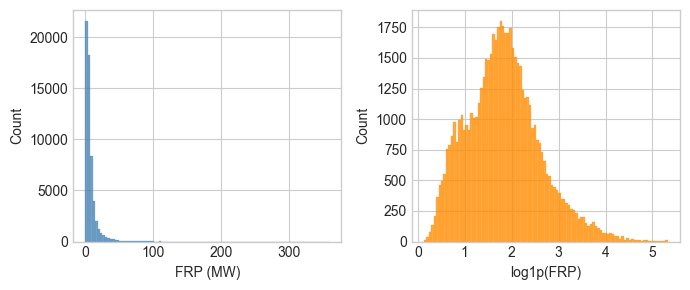

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(7, 3))

sns.histplot(df['frp'], bins=100, ax=axes[0], color='steelblue', edgecolor='steelblue')
axes[0].set_xlabel('FRP (MW)')
axes[0].set_ylabel('Count')

sns.histplot(df['frp_log1p'], bins=100, ax=axes[1], color='darkorange', edgecolor='darkorange')
axes[1].set_xlabel('log1p(FRP)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}fig_frp_distribution.pdf')
plt.show()

### 1.2 FRP Distribution by Year

We compare the log-transformed FRP distribution across 2022, 2023, and 2024
to assess whether El Niño amplified fire intensity at the median level or
primarily in the extremes.

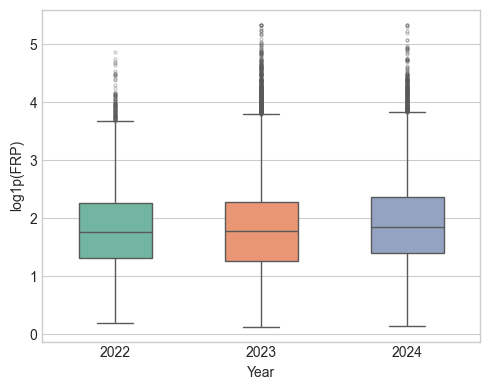

In [7]:
fig, ax = plt.subplots(figsize=(5, 4))

sns.boxplot(
    data=df,
    x='year',           # adjust column name if different
    y='frp_log1p',
    hue='year',
    palette='Set2',
    width=0.5,
    legend=False,
    flierprops=dict(marker='o', markersize=2, alpha=0.3),
    ax=ax
)

ax.set_xlabel('Year')
ax.set_ylabel('log1p(FRP)')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}fig_frp_by_year.pdf')
plt.show()

### 1.3 Empirical CDF and Percentile Thresholds

The empirical CDF shows where extreme values begin in the distribution.
We use this to define a statistically grounded outlier threshold for
Phase 3, rather than an arbitrary MW cutoff.

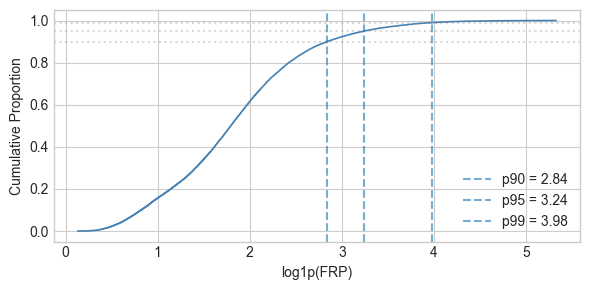

p 90.0: log1p(FRP) = 2.838  →  FRP ≈ 16.1 MW
p 95.0: log1p(FRP) = 3.242  →  FRP ≈ 24.6 MW
p 99.0: log1p(FRP) = 3.981  →  FRP ≈ 52.6 MW
p 99.5: log1p(FRP) = 4.231  →  FRP ≈ 67.8 MW


In [8]:
sorted_frp = np.sort(df['frp_log1p'])
cdf = np.arange(1, len(sorted_frp) + 1) / len(sorted_frp)

fig, ax = plt.subplots(figsize=(6,3))
ax.plot(sorted_frp, cdf, color='steelblue', linewidth=1.2)

# Mark key percentiles
for p in [0.90, 0.95, 0.99]:
    val = np.percentile(df['frp_log1p'], p * 100)
    ax.axvline(val, linestyle='--', alpha=0.6, label=f'p{int(p*100)} = {val:.2f}')
    ax.axhline(p, linestyle=':', alpha=0.3, color='gray')

ax.set_xlabel('log1p(FRP)')
ax.set_ylabel('Cumulative Proportion')
ax.legend()

plt.tight_layout()
plt.savefig(f'{FIG_DIR}fig_frp_ecdf.pdf', dpi=150)
plt.show()

# Print the raw numbers
for p in [90, 95, 99, 99.5]:
    val = np.percentile(df['frp_log1p'], p)
    raw_equiv = np.expm1(val)  # back-transform for interpretability
    print(f"p{p:5.1f}: log1p(FRP) = {val:.3f}  →  FRP ≈ {raw_equiv:.1f} MW")

## 2. Temporal Structure

### 2.1 Monthly FRP Intensity and Detection Count

We separate fire *intensity* (mean log1p FRP) from fire *count* (number of
detections) to understand whether El Niño amplified how many fires occurred
or how intensely they burned. Visual inspection suggests that
intensity peaked approximately one month before count — suggesting drought
first intensified existing fires before triggering mass ignition events.

In [9]:
monthly = (
    df.groupby('year_month')
    .agg(mean_frp=('frp_log1p', 'mean'),
         count=('frp_log1p', 'count'))
    .reset_index()
)
monthly['year_month_dt'] = monthly['year_month'].dt.to_timestamp()

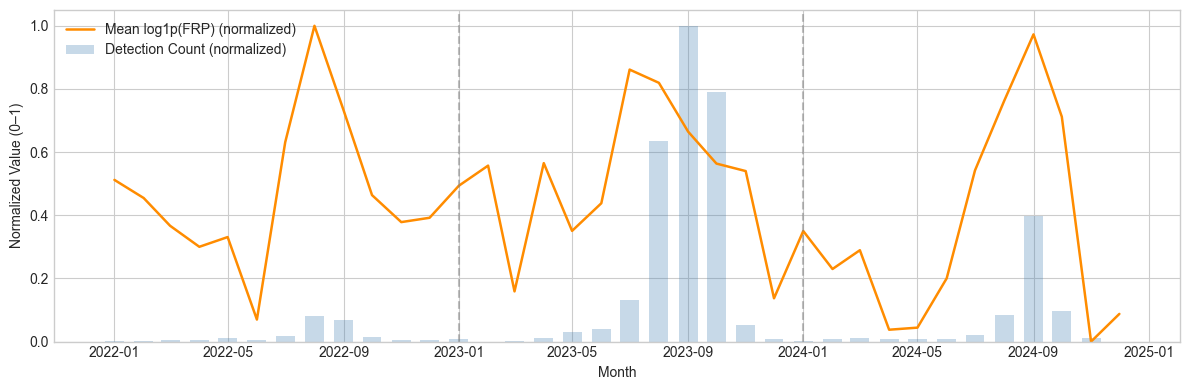

In [10]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
monthly['mean_frp_norm'] = scaler.fit_transform(monthly[['mean_frp']])
monthly['count_norm'] = scaler.fit_transform(monthly[['count']])

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(monthly['year_month_dt'], monthly['mean_frp_norm'],
        color='darkorange', linewidth=1.8, label='Mean log1p(FRP) (normalized)')
ax.bar(monthly['year_month_dt'], monthly['count_norm'],
       width=20, alpha=0.3, color='steelblue', label='Detection Count (normalized)')

ax.set_ylabel('Normalized Value (0–1)')
ax.set_xlabel('Month')
ax.legend()

for year in [2023, 2024]:
    ax.axvline(pd.Timestamp(f'{year}-01-01'),
               color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}fig_monthly_frp_normalized.pdf')
plt.show()

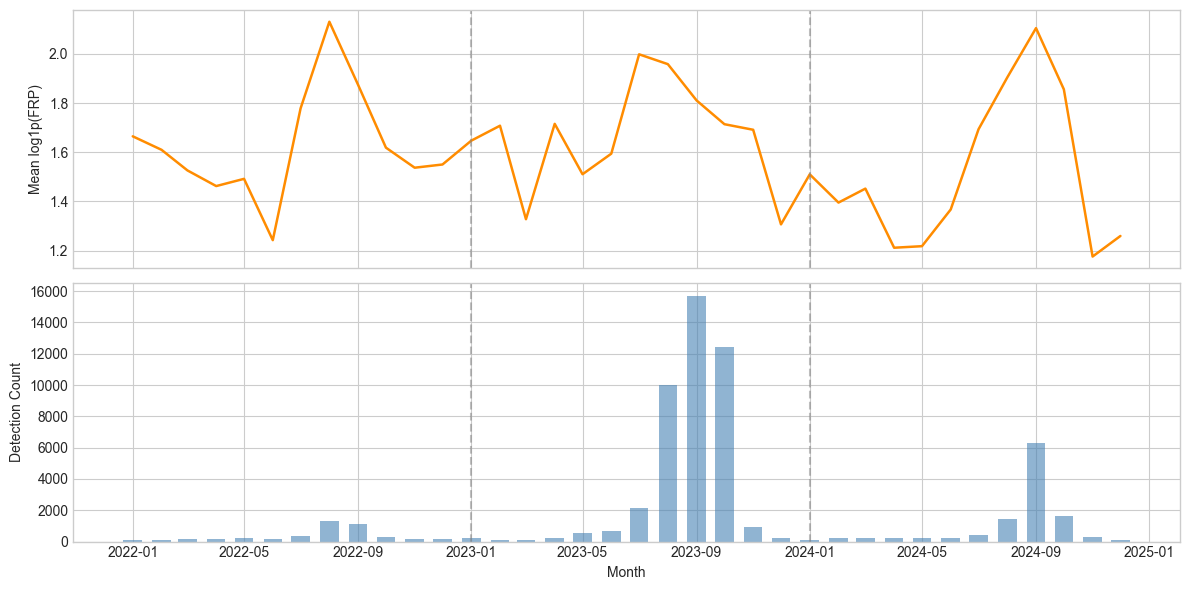

In [11]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Top panel: mean FRP
ax1.plot(monthly['year_month_dt'], monthly['mean_frp'],
         color='darkorange', linewidth=1.8)
ax1.set_ylabel('Mean log1p(FRP)')

# Bottom panel: detection count
ax2.bar(monthly['year_month_dt'], monthly['count'],
        width=20, alpha=0.6, color='steelblue')
ax2.set_ylabel('Detection Count')
ax2.set_xlabel('Month')

# Year separators on both panels
for year in [2023, 2024]:
    for ax in [ax1, ax2]:
        ax.axvline(pd.Timestamp(f'{year}-01-01'),
                   color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}fig_monthly_frp_stacked.pdf')
plt.show()

### 2.2 Median FRP by Year and Month

A year × month heatmap shows seasonal patterns more compactly. August–September
consistently shows the highest median FRP across all years, confirming the dry
season signal. Note that 2022-August has the single highest median cell despite
low detection count — a small number of extremely intense fires, distinct from
the 2023 mass ignition pattern.

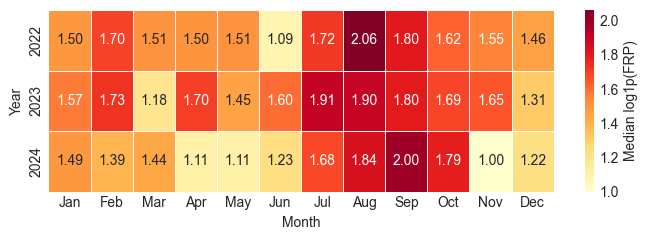

In [12]:
pivot = df.pivot_table(
    values='frp_log1p',
    index='year',
    columns='month',
    aggfunc='median'
)

month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(7, 2.5))
sns.heatmap(
    pivot,
    ax=ax,
    cmap='YlOrRd',
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    xticklabels=month_labels,
    cbar_kws={'label': 'Median log1p(FRP)'}
)
ax.set_xlabel('Month')
ax.set_ylabel('Year')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}fig_frp_heatmap.pdf')
plt.show()

### 2.3 Weekly Fire Detection Count

Weekly resolution reveals the sharpness of dry season fire activity and
identifies natural quiet periods (November–July) where detection counts
approach zero. These gaps serve as natural boundaries for sliding window
cross-validation fold design.

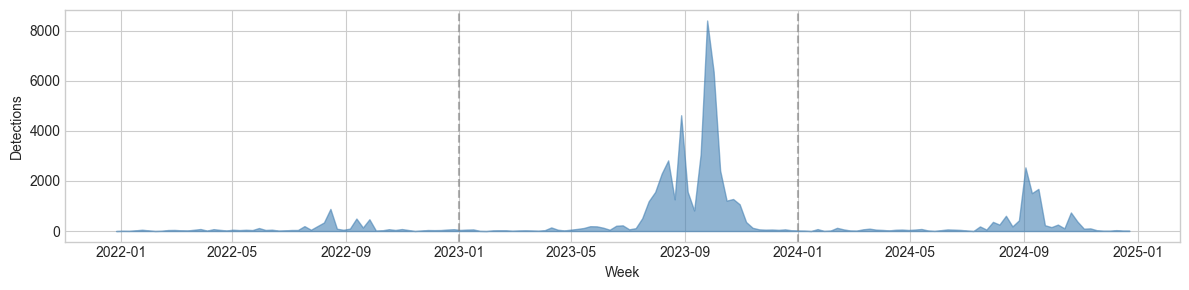

In [13]:
weekly = (
    df.groupby(df['acq_date'].dt.to_period('W'))
    .size()
    .reset_index(name='count')
)
weekly['week_dt'] = weekly['acq_date'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(12, 3))
ax.fill_between(weekly['week_dt'], weekly['count'],
                alpha=0.6, color='steelblue')
ax.set_xlabel('Week')
ax.set_ylabel('Detections')

for year in [2023, 2024]:
    ax.axvline(pd.Timestamp(f'{year}-01-01'), color='gray',
               linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}fig_weekly_detections.pdf')
plt.show()

## 3. Outlier Analysis

### 3.1 Defining the Outlier Threshold

We define extreme fire events statistically using the 99th percentile of
`frp_log1p`. No physically-grounded FRP threshold exists in the literature,
so p99 provides a reproducible, data-driven boundary for investigation.

In [14]:
OUTLIER_THRESHOLD = df['frp_log1p'].quantile(0.99)  # ~3.98

df['is_outlier'] = (df['frp_log1p'] > OUTLIER_THRESHOLD).astype(int)
outlier_df = df[df['is_outlier'] == 1].copy()

print(f"Outlier threshold: {OUTLIER_THRESHOLD:.3f} (≈ {np.expm1(OUTLIER_THRESHOLD):.1f} MW)")
print(f"Outlier count: {df['is_outlier'].sum()} of {len(df)} ({df['is_outlier'].mean()*100:.2f}%)")

Outlier threshold: 3.981 (≈ 52.6 MW)
Outlier count: 592 of 59155 (1.00%)


### 3.2 Temporal Distribution of Extreme Events

We cross-tabulate extreme events by year and month to assess whether they
concentrate in the 2023 El Niño dry season or are spread uniformly across
the study period.

In [15]:
print("Outliers by year:")
print(outlier_df['year'].value_counts().sort_index())

Outliers by year:
year
2022     36
2023    367
2024    189
Name: count, dtype: int64


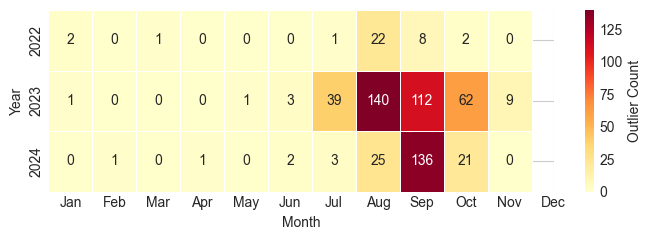

In [16]:
# Heatmap: outlier count by year × month
outlier_pivot = outlier_df.pivot_table(
    values='frp_log1p',
    index='year',
    columns='month',
    aggfunc='count',
    fill_value=0
)

fig, ax = plt.subplots(figsize=(7, 2.5))
sns.heatmap(
    outlier_pivot,
    ax=ax,
    cmap='YlOrRd',
    annot=True,
    fmt='d',
    linewidths=0.5,
    xticklabels=['Jan','Feb','Mar','Apr','May','Jun',
                 'Jul','Aug','Sep','Oct','Nov','Dec'],
    cbar_kws={'label': 'Outlier Count'}
)
ax.set_xlabel('Month')
ax.set_ylabel('Year')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}fig_outlier_heatmap.pdf')
plt.show()

### 3.3 Outliers vs Peat Type Class

We check whether extreme events concentrate on deep peat areas (class 2),
which would confirm physical coherence. The outlier rate per class and the
full FRP distribution per class are examined separately.

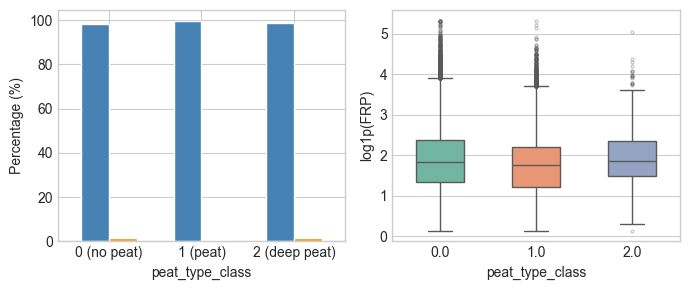

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(7, 3))

# Left: peat_type_class distribution — outliers vs non-outliers
peat_outlier = df.groupby(['peat_type_class', 'is_outlier']).size().unstack(fill_value=0)
peat_outlier_pct = peat_outlier.div(peat_outlier.sum(axis=1), axis=0) * 100

peat_outlier_pct.plot(kind='bar', ax=axes[0], color=['steelblue', 'darkorange'],
                      width=0.6, edgecolor='white', legend=False)
axes[0].set_xlabel('peat_type_class')
axes[0].set_ylabel('Percentage (%)')
axes[0].set_xticklabels(['0 (no peat)', '1 (peat)', '2 (deep peat)'], rotation=0)

# Right: box plot of frp_log1p by peat_type_class
sns.boxplot(data=df, x='peat_type_class', y='frp_log1p',
            palette='Set2', width=0.5, hue='peat_type_class',
            flierprops=dict(marker='o', markersize=2, alpha=0.3),
            ax=axes[1], legend=False)
axes[1].set_xlabel('peat_type_class')
axes[1].set_ylabel('log1p(FRP)')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}fig_outlier_peat.pdf')
plt.show()

### 3.4 Spatial Distribution of Extreme Events

Geographic clustering of extreme events in known peatland areas would
confirm they are physically coherent fire detections, not sensor artifacts.

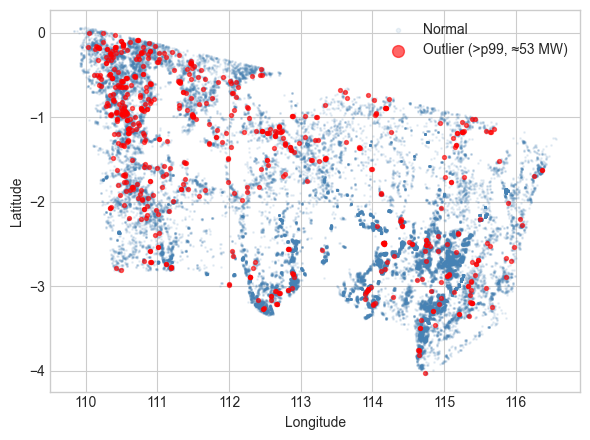

In [18]:
fig, ax = plt.subplots(figsize=(6, 4.5))

# Non-outliers as background
ax.scatter(df[df['is_outlier']==0]['longitude'],
           df[df['is_outlier']==0]['latitude'],
           s=1, alpha=0.1, color='steelblue', label='Normal',
           rasterized=True)

# Outliers on top
ax.scatter(outlier_df['longitude'],
           outlier_df['latitude'],
           s=8, alpha=0.6, color='red', label=f'Outlier (>p99, ≈53 MW)',
           rasterized=True)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(markerscale=3)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}fig_outlier_spatial.pdf', dpi=300)
plt.show()

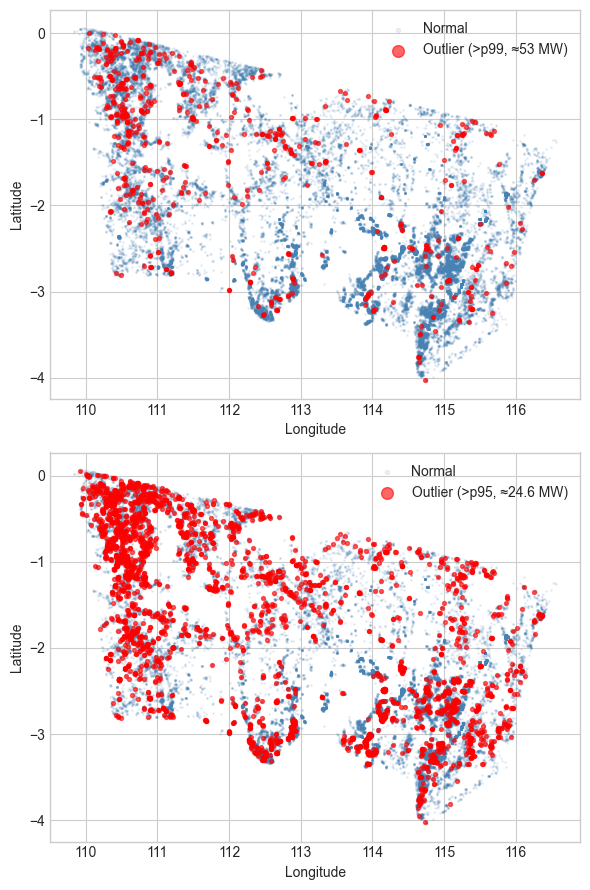

In [19]:
p95_threshold = df['frp_log1p'].quantile(0.95)
p95_df = df[df['frp_log1p'] > p95_threshold].copy()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 9))

for ax, ref_df, label, threshold in [
    (ax1, outlier_df, f'Outlier (>p99, ≈53 MW)', OUTLIER_THRESHOLD),
    (ax2, p95_df, f'Outlier (>p95, ≈24.6 MW)', p95_threshold)
]:
    ax.scatter(df[df['frp_log1p'] <= threshold]['longitude'],
               df[df['frp_log1p'] <= threshold]['latitude'],
               s=1, alpha=0.1, color='steelblue', label='Normal',
               rasterized=True)
    ax.scatter(ref_df['longitude'], ref_df['latitude'],
               s=8, alpha=0.6, color='red', label=label,
               rasterized=True)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.legend(markerscale=3)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}fig_outlier_spatial_comparison.pdf')
plt.show()

### 3.5 Decision: Retain All Extreme Events

Extreme events (>p99, ≈53 MW) show temporal concentration in 2023 Aug–Sep
(43% of all outliers), geographic clustering in Central and South Kalimantan
peatland areas, and physical coherence with El Niño drought conditions.
They are retained as a scientifically meaningful subpopulation.

Note: 2024-September contains 136 extreme events despite neutral ENSO
(ONI = −0.17, DMI = 0.05). This anomaly remains unexplained by standard
climate indices and will be discussed as a caveat in the Discussion section.

## 4. Feature Selection

### 4.1 Candidate Feature Set

We begin with all available columns, excluding identifiers, targets, temporal
columns replaced by circular encodings, and columns already dropped in earlier
phases (`oni_index`, `dmi_index`, `is_dry_season`, `is_outlier`).

In [20]:
drop_cols = [
    'frp', 'frp_log1p',       # target + raw target
    'acq_date', 'enso_phase', # non-numeric
    'year_month',             # period type
    'year', 'month',          # temporal identifiers, not features
    'latitude', 'longitude',  # spatial identifiers
    'acq_time',               # replaced by circular encodings
    'doy',                    # replaced by circular encodings
    'hour_wib_decimal',       # replaced by circular encodings
    'is_outlier',             # analysis label, not a feature
]

feature_cols = [c for c in df.columns if c not in drop_cols]
print(f"Candidate features: {len(feature_cols)}")
print(feature_cols)

Candidate features: 33
['ndvi', 'evi', 'ndvi_age_days', 'ndwi', 'lst_day', 'lst_night', 'land_cover_type', 'peat_type_class', 'ssrd', 't2m', 'd2m', 'u10', 'v10', 'tp_hourly', 'mjo_phase', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'is_peak_burn_window', 'solar_insolation_proxy', 'vpd_kpa', 'wind_speed_m_s', 'fuel_dryness', 'hdasi', 'wffsp', 'diurnal_burn_potential', 'dist_river_m', 'dist_road_m', 'pop_density', 'dist_settlement_m', 'forest_clearance_index', 'dist_settlement_osm_m']


### 4.2 Spearman Correlation — Justification and Method

We use Spearman over Pearson for two reasons: `frp_log1p` remains moderately
skewed after transformation, and fire-meteorology relationships are physically
nonlinear. Spearman captures monotonic relationships regardless of distribution
shape, making it more appropriate here.

Before computing the full correlation matrix, we inspect `mjo_phase` separately.
Its uniform distribution across 8 phases (each ~7,300 rows) suggests no
preferential association between MJO phase and fire activity. A strong predictor
would be expected to show non-uniform distribution in a fire detection dataset.

In [21]:
print(df['mjo_phase'].value_counts().sort_index())
print()
r, p = spearmanr(df['mjo_phase'], df['frp_log1p'])
print(f"Spearman r: {r:.4f}, p-value: {p:.4f}")

mjo_phase
1.0    7331
2.0    7450
3.0    7375
4.0    7274
5.0    7507
6.0    7479
7.0    7448
8.0    7291
Name: count, dtype: int64

Spearman r: -0.0067, p-value: 0.1042


### 4.3 Spearman Correlation Matrix

`mjo_phase` is dropped before computation: uniform distribution and
non-significant Spearman r (−0.007, p = 0.10) confirm it carries no
discriminative signal for FRP prediction.

Both r and p-value are used for feature decisions. A feature must show
both meaningful r (|r| > 0.05) and statistical significance (p < 0.05)
to be retained on correlation grounds alone.

In [22]:
# Final feature list — 32 features
feature_cols = [c for c in feature_cols if c != 'mjo_phase']

# Compute Spearman correlation matrix
corr_matrix, p_matrix = spearmanr(df[feature_cols + ['frp_log1p']])

# Convert to DataFrames
all_cols = feature_cols + ['frp_log1p']
corr_df = pd.DataFrame(corr_matrix, index=all_cols, columns=all_cols)
p_df = pd.DataFrame(p_matrix, index=all_cols, columns=all_cols)

# Extract correlations with frp_log1p only
target_corr = corr_df['frp_log1p'].drop('frp_log1p').sort_values(key=abs, ascending=False)
target_pval = p_df['frp_log1p'].drop('frp_log1p')

# Combine into summary table
corr_summary = pd.DataFrame({
    'spearman_r': target_corr,
    'p_value': target_pval[target_corr.index],
    'significant': target_pval[target_corr.index] < 0.05
})

print(corr_summary.to_string())

                        spearman_r        p_value  significant
is_peak_burn_window       0.650975   0.000000e+00         True
diurnal_burn_potential    0.522963   0.000000e+00         True
t2m                       0.517034   0.000000e+00         True
hdasi                     0.512128   0.000000e+00         True
vpd_kpa                   0.509786   0.000000e+00         True
solar_insolation_proxy    0.508272   0.000000e+00         True
hour_sin                 -0.505008   0.000000e+00         True
hour_cos                 -0.503974   0.000000e+00         True
ssrd                     -0.439800   0.000000e+00         True
d2m                      -0.206886   0.000000e+00         True
dist_settlement_m        -0.194095   0.000000e+00         True
wind_speed_m_s            0.181156   0.000000e+00         True
pop_density              -0.175504   0.000000e+00         True
land_cover_type          -0.171487   0.000000e+00         True
evi                       0.171211   0.000000e+00      

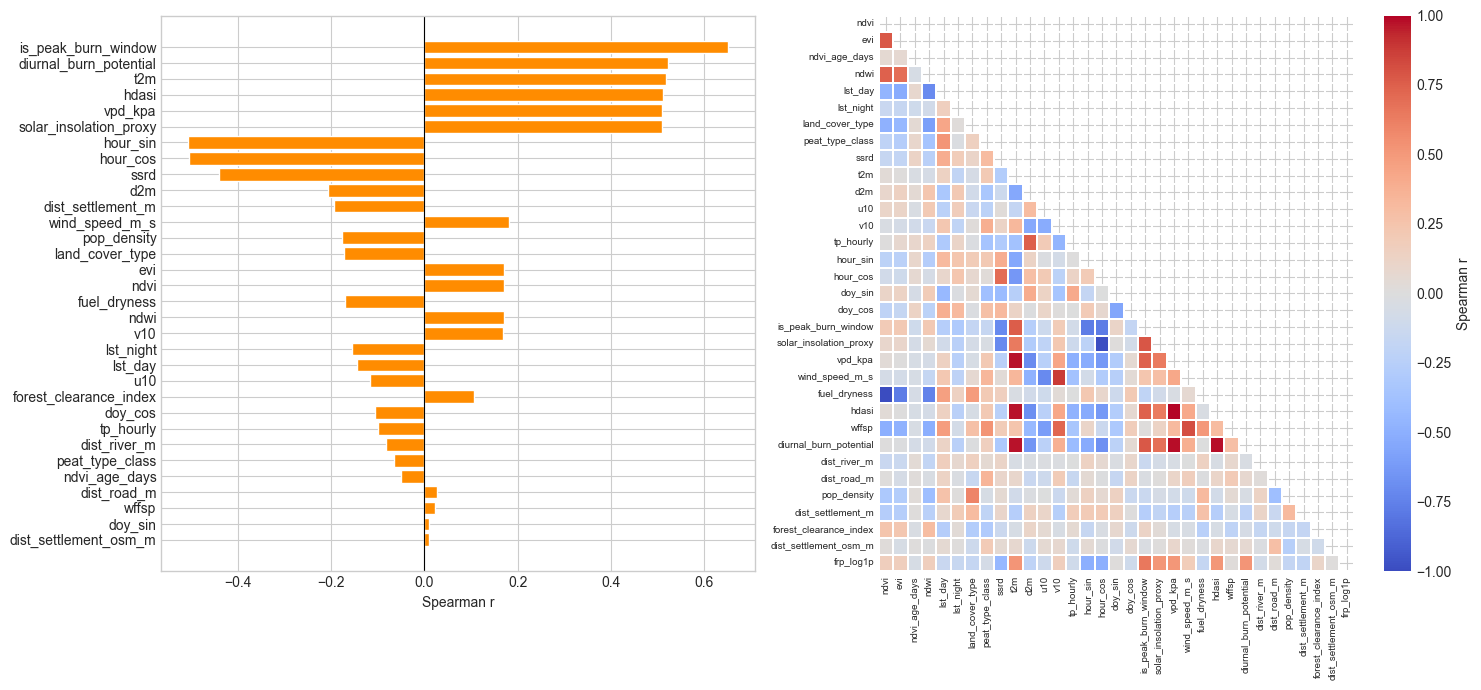

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Left: bar chart ranked by |r| with frp_log1p
colors = ['darkorange' if s else 'lightgray'
          for s in corr_summary['significant']]

axes[0].barh(corr_summary.index[::-1],
             corr_summary['spearman_r'][::-1],
             color=colors[::-1], edgecolor='white')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('Spearman r')

# Right: full correlation heatmap
mask = np.zeros_like(corr_df, dtype=bool)
mask[np.triu_indices_from(mask)] = True  # upper triangle only

sns.heatmap(
    corr_df,
    mask=mask,
    ax=axes[1],
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.1,
    cbar_kws={'label': 'Spearman r'},
    xticklabels=True,
    yticklabels=True
)
axes[1].tick_params(axis='x', rotation=90, labelsize=7)
axes[1].tick_params(axis='y', labelsize=7)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}fig_spearman_matrix.pdf')
plt.show()

### 4.4 Feature Drop Decisions

Based on the Spearman matrix and domain knowledge, the following features
are dropped:

**Derived from other retained features (redundant ingredients):**
- `hdasi` — derived from `t2m` and `vpd_kpa`
- `diurnal_burn_potential` — derived from `lst_day` and `lst_night`
- `fuel_dryness` — monotonic transformation of `ndvi` (1/max(ndvi, 0.05))
- `wffsp` — derived from `wind_speed_m_s` and `fuel_dryness`; `fuel_dryness` dropped
- `t2m`, `d2m` — redundant with `vpd_kpa`, which is derived from both
- `u10`, `v10` — redundant with `wind_speed_m_s`, which is derived from both

**Redundant with circular time encodings:**
- `is_peak_burn_window` — tree-based models learn equivalent time window splits
  from `hour_sin`/`hour_cos` directly

**Correlated cluster — derivation unclear:**
- `solar_insolation_proxy` — strongly correlated with `vpd_kpa`, `hdasi`, and
  `diurnal_burn_potential`; exact derivation unconfirmed by teammate

**Vegetation indices — keep EVI only:**
- `ndvi`, `ndwi` — dropped in favour of `evi`, which is more robust under
  smoky atmospheric conditions prevalent in Kalimantan during fire season

**Anthropogenic features — predict ignition, not intensity:**
- `dist_river_m`, `dist_road_m`, `dist_settlement_m`, `dist_settlement_osm_m`,
  `pop_density`, `forest_clearance_index` — weak Spearman with FRP; domain
  insight: anthropogenic variables discriminate ignition probability, not fire
  radiative power once a fire is actively burning. Reported as a finding in
  Results/Discussion.

In [24]:
FEATURES_TO_DROP = [
    'is_peak_burn_window',    # redundant with hour_sin/hour_cos
    'hdasi',                  # derived from t2m + vpd_kpa
    'diurnal_burn_potential', # derived from lst_day + lst_night
    'solar_insolation_proxy', # redundant correlated cluster
    't2m', 'd2m',             # redundant with vpd_kpa
    'u10', 'v10',             # redundant with wind_speed_m_s
    'fuel_dryness',           # monotonic transform of ndvi
    'ndvi', 'ndwi',           # keep evi only
    'wffsp',                  # derived from wind_speed_m_s + fuel_dryness
    'dist_river_m', 'dist_road_m', 'dist_settlement_m',
    'dist_settlement_osm_m', 'pop_density', 'forest_clearance_index',
]

feature_cols = [c for c in feature_cols if c not in FEATURES_TO_DROP]

print(f"Final feature count: {len(feature_cols)}")
print(feature_cols)

Final feature count: 14
['evi', 'ndvi_age_days', 'lst_day', 'lst_night', 'land_cover_type', 'peat_type_class', 'ssrd', 'tp_hourly', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'vpd_kpa', 'wind_speed_m_s']


## 5. Cross-Validation Design

### 5.1 Custom Sliding Window Splitter

We use a date-range-based sliding window splitter rather than
`sklearn.TimeSeriesSplit` for two reasons:

1. `TimeSeriesSplit` splits by row count, not time period. Because ~47% of
   detections fall in the 2023 dry season, row-based folds would represent
   unequal time periods — some folds spanning weeks, others spanning months.

2. `TimeSeriesSplit` implements expanding windows natively. A sliding window
   requires a workaround that obscures the logic.

Parameters chosen:
- **Train window:** 12 months — ensures the model sees one full annual cycle
  (wet + dry season) before predicting
- **Test window:** 3 months — wide enough to capture both peak and transition
  periods within a single fold
- **Step size:** 2 months — balances fold count (11 folds) against
  computational cost, especially for AutoGluon

4 of 11 folds have test windows overlapping the 2023 El Niño peak
(Aug–Oct 2023), providing repeated stress-testing on out-of-distribution
extreme fire conditions.

In [25]:
def sliding_window_splits(df, date_col, train_months, test_months, step_months):
    """
    Generate sliding window train/test index splits based on date ranges.

    Parameters
    ----------
    df : pd.DataFrame
    date_col : str — name of datetime column
    train_months : int — training window size in months
    test_months : int — test window size in months
    step_months : int — step size between folds in months

    Yields
    ------
    (train_idx, test_idx): tuple of np.ndarray
    """
    dates = df[date_col]
    start = dates.min()
    end = dates.max()

    fold_start = start
    while True:
        train_end = fold_start + relativedelta(months=train_months)
        test_end = train_end + relativedelta(months=test_months)

        if test_end > end:
            break

        train_idx = df.index[(dates >= fold_start) & (dates < train_end)].to_numpy()
        test_idx = df.index[(dates >= train_end) & (dates < test_end)].to_numpy()

        if len(train_idx) > 0 and len(test_idx) > 0:
            yield train_idx, test_idx

        fold_start += relativedelta(months=step_months)

TRAIN_MONTHS = 12
TEST_MONTHS = 3
STEP_MONTHS = 2

splits = list(sliding_window_splits(
    df, 'acq_date', TRAIN_MONTHS, TEST_MONTHS, STEP_MONTHS
))

print(f"Total folds: {len(splits)}")
for i, (tr, te) in enumerate(splits):
    tr_start = df.loc[tr, 'acq_date'].min().strftime('%Y-%m')
    tr_end = df.loc[tr, 'acq_date'].max().strftime('%Y-%m')
    te_start = df.loc[te, 'acq_date'].min().strftime('%Y-%m')
    te_end = df.loc[te, 'acq_date'].max().strftime('%Y-%m')
    print(f"Fold {i+1:2d}: train [{tr_start} → {tr_end}]  test [{te_start} → {te_end}]  "
          f"(train n={len(tr):,}, test n={len(te):,})")

Total folds: 11
Fold  1: train [2022-01 → 2022-12]  test [2023-01 → 2023-03]  (train n=4,485, test n=399)
Fold  2: train [2022-03 → 2023-02]  test [2023-03 → 2023-05]  (train n=4,572, test n=918)
Fold  3: train [2022-05 → 2023-04]  test [2023-05 → 2023-07]  (train n=4,564, test n=3,405)
Fold  4: train [2022-07 → 2023-06]  test [2023-07 → 2023-09]  (train n=5,388, test n=27,894)
Fold  5: train [2022-09 → 2023-08]  test [2023-09 → 2023-11]  (train n=15,872, test n=29,063)
Fold  6: train [2022-11 → 2023-10]  test [2023-11 → 2024-01]  (train n=42,585, test n=1,268)
Fold  7: train [2023-01 → 2023-12]  test [2024-01 → 2024-03]  (train n=43,391, test n=607)
Fold  8: train [2023-03 → 2024-02]  test [2024-03 → 2024-05]  (train n=43,452, test n=647)
Fold  9: train [2023-05 → 2024-04]  test [2024-05 → 2024-07]  (train n=43,540, test n=795)
Fold 10: train [2023-07 → 2024-06]  test [2024-07 → 2024-09]  (train n=42,684, test n=8,101)
Fold 11: train [2023-09 → 2024-08]  test [2024-09 → 2024-11]  (tra

### 5.2 Fold Visualization

We visualize the fold boundaries overlaid on the monthly detection count
to confirm that test folds cover both peak and quiet periods, and that
the 2023 El Niño peak is explicitly included in multiple test windows.

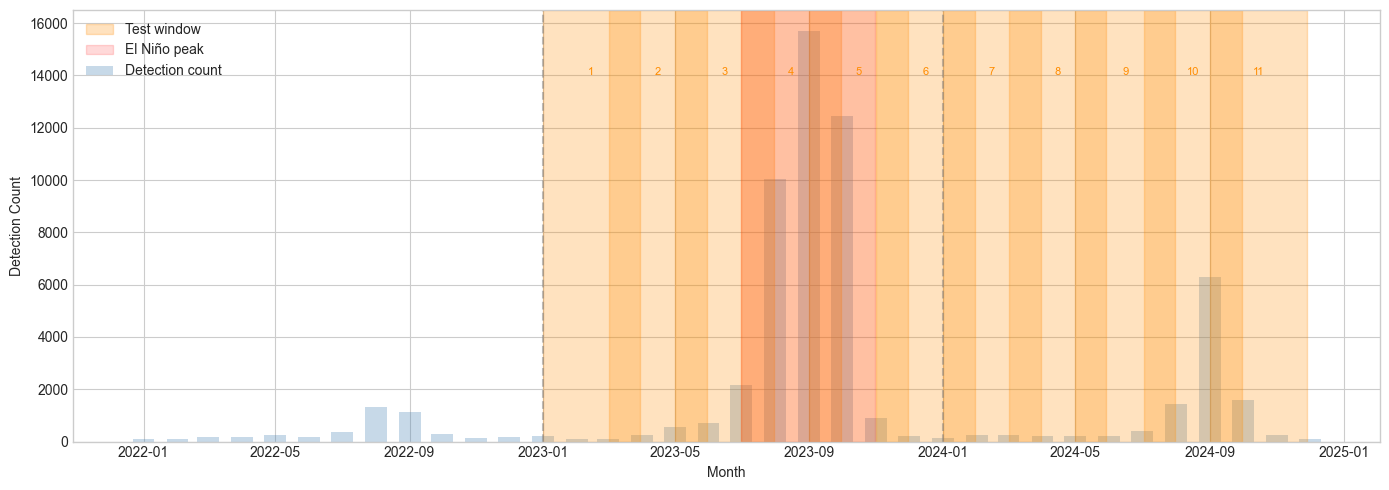

In [26]:
EL_NINO_START = pd.Timestamp('2023-07-01')
EL_NINO_END = pd.Timestamp('2023-10-31')

fig, ax = plt.subplots(figsize=(14, 5))

# Background: monthly detection count
ax.bar(monthly['year_month_dt'], monthly['count'],
       width=20, alpha=0.3, color='steelblue', label='Detection count')

# Fold bands
colors_train = plt.cm.Blues(np.linspace(0.3, 0.7, len(splits)))
for i, (tr, te) in enumerate(splits):
    te_start = df.loc[te, 'acq_date'].min()
    te_end = df.loc[te, 'acq_date'].max()
    ax.axvspan(te_start, te_end, alpha=0.25, color='darkorange',
               label='Test window' if i == 0 else '')
    ax.text(te_start + (te_end - te_start) / 2, ax.get_ylim()[1] * 0.85,
            str(i + 1), ha='center', fontsize=8, color='darkorange')

# El Niño region
ax.axvspan(EL_NINO_START, EL_NINO_END, alpha=0.15, color='red',
           label='El Niño peak')

ax.set_xlabel('Month')
ax.set_ylabel('Detection Count')
ax.legend()

for year in [2023, 2024]:
    ax.axvline(pd.Timestamp(f'{year}-01-01'), color='gray',
               linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}fig_cv_folds.pdf')
plt.show()

### 5.3 Evaluation Note

Due to the severe imbalance in fold sizes — Folds 4 and 5 contain ~27,000–29,000
detections while quiet-period folds contain fewer than 1,000 — aggregate CV
metrics would be dominated by El Niño peak performance. Per-fold metrics are
therefore reported alongside aggregate scores to distinguish model behaviour
on peak vs quiet fire periods.